# EDA 13.2: Shipping Fee Analysis

This notebook analyzes shipping fee distribution, free-shipping behavior, AOV by shipping fee group, regional shipping fee patterns, and whether shipping-fee signals support business recommendations or useful lagged features.

## 1. Setup and File Discovery

Locate required and optional CSV files under the current working directory. Missing files generate warnings and the notebook continues where possible.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 240)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT = Path.cwd()
FILES = ['shipments.csv', 'orders.csv', 'geography.csv', 'payments.csv', 'order_items.csv', 'customers.csv']
REQUIRED = {'shipments.csv', 'orders.csv', 'geography.csv'}

def normalize_name(name):
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())

def discover_csvs(root):
    found = {}
    for path in root.rglob('*.csv'):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in FILES}
file_status = pd.DataFrame([
    {'file': name, 'required': name in REQUIRED, 'found': path is not None, 'path': str(path) if path else None}
    for name, path in selected_paths.items()
])
display(file_status)

for name, path in selected_paths.items():
    if path is None and name in REQUIRED:
        warnings.warn(f'Required file missing: {name}. The notebook will continue where possible.')

,file,required,found,path
0,shipments.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\sh...
1,orders.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
2,geography.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\ge...
3,payments.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\pa...
4,order_items.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
5,customers.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\cu...


## 2. Load Shipments, Orders, Geography, and Optional Files

Load all available files safely with pandas and display basic schema context.

In [2]:
def load_csv_safe(path):
    if path is None:
        return None
    try:
        return pd.read_csv(path)
    except Exception as exc:
        warnings.warn(f'Failed to load {path}: {exc}')
        return None

data = {name.replace('.csv', ''): load_csv_safe(path) for name, path in selected_paths.items()}
shipments = data.get('shipments')
orders = data.get('orders')
geography = data.get('geography')
payments = data.get('payments')
order_items = data.get('order_items')
customers = data.get('customers')

schema_rows = []
for name, df in data.items():
    schema_rows.append({
        'dataset': name,
        'loaded': df is not None,
        'rows': None if df is None else len(df),
        'columns': None if df is None else ', '.join(map(str, df.columns[:20]))
    })
display(pd.DataFrame(schema_rows))

C:\Users\ACER\AppData\Local\Temp\ipykernel_6120\4175614461.py:5: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


,dataset,loaded,rows,columns
0,shipments,True,566067,"order_id, ship_date, delivery_date, shipping_fee"
1,orders,True,646945,"order_id, order_date, customer_id, zip, order_..."
2,geography,True,39948,"zip, city, region, district"
3,payments,True,646945,"order_id, payment_method, payment_value, insta..."
4,order_items,True,714669,"order_id, product_id, quantity, unit_price, di..."
5,customers,True,121930,"customer_id, zip, city, signup_date, gender, a..."


## 3. Identify Shipping Fee, Order Value, Region, Status, and Date Columns

Use tolerant matching for likely naming variations. If order value is missing from `orders.csv`, the notebook infers it from `payments.csv` first and `order_items.csv` second.

In [3]:
def normalized_map(columns):
    return {normalize_name(c): c for c in columns}

def find_column(columns, candidates, contains=False):
    nmap = normalized_map(columns)
    normalized_candidates = [normalize_name(c) for c in candidates]
    for cand in normalized_candidates:
        if cand in nmap:
            return nmap[cand]
    if contains:
        for cand in normalized_candidates:
            for ncol, raw in nmap.items():
                if cand in ncol:
                    return raw
    return None

shipment_cols = {}
if shipments is not None:
    shipment_cols = {
        'shipment_id': find_column(shipments.columns, ['shipment_id', 'shipping_id', 'id'], contains=True),
        'order_id': find_column(shipments.columns, ['order_id']),
        'customer_id': find_column(shipments.columns, ['customer_id'], contains=True),
        'shipment_date': find_column(shipments.columns, ['ship_date', 'shipment_date', 'shipped_date', 'dispatch_date'], contains=True),
        'delivery_date': find_column(shipments.columns, ['delivery_date', 'delivered_date'], contains=True),
        'shipping_fee': find_column(shipments.columns, ['shipping_fee', 'freight', 'delivery_fee', 'shipping_cost', 'shipping'], contains=True),
        'zip': find_column(shipments.columns, ['zip', 'postal_code', 'zipcode'], contains=True),
        'region': find_column(shipments.columns, ['region', 'state', 'province']),
        'city': find_column(shipments.columns, ['city']),
        'shipping_method': find_column(shipments.columns, ['shipping_method', 'carrier', 'delivery_method'], contains=True),
    }

orders_cols = {}
if orders is not None:
    orders_cols = {
        'order_id': find_column(orders.columns, ['order_id']),
        'customer_id': find_column(orders.columns, ['customer_id'], contains=True),
        'order_date': find_column(orders.columns, ['order_date', 'date', 'created_at'], contains=True),
        'order_value': find_column(orders.columns, ['order_total', 'revenue', 'sales_amount', 'amount', 'total', 'gmv'], contains=True),
        'zip': find_column(orders.columns, ['zip', 'postal_code', 'zipcode'], contains=True),
        'order_status': find_column(orders.columns, ['order_status', 'status'], contains=True),
    }

geography_cols = {}
if geography is not None:
    geography_cols = {
        'zip': find_column(geography.columns, ['zip', 'postal_code', 'zipcode'], contains=True),
        'city': find_column(geography.columns, ['city']),
        'region': find_column(geography.columns, ['region', 'state', 'province']),
        'district': find_column(geography.columns, ['district']),
    }

payment_cols = {}
if payments is not None:
    payment_cols = {
        'order_id': find_column(payments.columns, ['order_id']),
        'payment_amount': find_column(payments.columns, ['payment_value', 'payment_amount', 'amount', 'value'], contains=True),
    }

order_item_cols = {}
if order_items is not None:
    order_item_cols = {
        'order_id': find_column(order_items.columns, ['order_id']),
        'quantity': find_column(order_items.columns, ['quantity', 'qty', 'units'], contains=True),
        'unit_price': find_column(order_items.columns, ['unit_price', 'price', 'selling_price'], contains=True),
        'discount_amount': find_column(order_items.columns, ['discount_amount', 'discount'], contains=True),
    }

identified = pd.DataFrame({
    'shipments': pd.Series(shipment_cols),
    'orders': pd.Series(orders_cols),
    'geography': pd.Series(geography_cols),
    'payments': pd.Series(payment_cols),
    'order_items': pd.Series(order_item_cols),
})
display(identified)

,shipments,orders,geography,payments,order_items
city,None,NaN,city,NaN,NaN
customer_id,None,customer_id,NaN,NaN,NaN
delivery_date,delivery_date,NaN,NaN,NaN,NaN
discount_amount,NaN,NaN,NaN,NaN,discount_amount
district,NaN,NaN,district,NaN,NaN
order_date,NaN,order_date,NaN,NaN,NaN
order_id,order_id,order_id,NaN,order_id,order_id
order_status,NaN,order_status,NaN,NaN,NaN
order_value,NaN,None,NaN,NaN,NaN
payment_amount,NaN,NaN,NaN,payment_value,NaN


## 4. Shipment and Shipping Fee Data Quality Checks

Standardize shipping fee and dates, then inspect missingness, zeros, negatives, and duplicates.

In [4]:
shipping_warnings = []
shipments_clean = None

if shipments is not None:
    shipments_clean = shipments.copy()
    shipments_clean['order_id_std'] = shipments_clean[shipment_cols['order_id']] if shipment_cols.get('order_id') else pd.NA
    shipments_clean['customer_id_std'] = shipments_clean[shipment_cols['customer_id']] if shipment_cols.get('customer_id') else pd.NA
    shipments_clean['shipment_date_std'] = pd.to_datetime(shipments_clean[shipment_cols['shipment_date']], errors='coerce') if shipment_cols.get('shipment_date') else pd.NaT
    shipments_clean['delivery_date_std'] = pd.to_datetime(shipments_clean[shipment_cols['delivery_date']], errors='coerce') if shipment_cols.get('delivery_date') else pd.NaT
    shipments_clean['shipping_fee_std'] = pd.to_numeric(shipments_clean[shipment_cols['shipping_fee']], errors='coerce') if shipment_cols.get('shipping_fee') else np.nan
    shipments_clean['zip_std'] = shipments_clean[shipment_cols['zip']] if shipment_cols.get('zip') else pd.NA
    shipments_clean['region_std'] = shipments_clean[shipment_cols['region']] if shipment_cols.get('region') else pd.NA
    shipments_clean['city_std'] = shipments_clean[shipment_cols['city']] if shipment_cols.get('city') else pd.NA

    quality = pd.DataFrame([{
        'shipment_rows': len(shipments_clean),
        'shipment_date_min': shipments_clean['shipment_date_std'].min(),
        'shipment_date_max': shipments_clean['shipment_date_std'].max(),
        'missing_order_ids': int(shipments_clean['order_id_std'].isna().sum()),
        'missing_shipping_fees': int(shipments_clean['shipping_fee_std'].isna().sum()),
        'zero_shipping_fees': int(shipments_clean['shipping_fee_std'].fillna(0).eq(0).sum()),
        'negative_shipping_fees': int(shipments_clean['shipping_fee_std'].fillna(0).lt(0).sum()),
        'duplicate_order_records': int(shipments_clean.duplicated(subset=['order_id_std']).sum()),
    }])
    display(quality)
    display(shipments_clean['shipping_fee_std'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).to_frame('shipping_fee_summary'))

    if quality.loc[0, 'missing_shipping_fees'] > 0:
        shipping_warnings.append(f"{quality.loc[0, 'missing_shipping_fees']} shipment rows have missing shipping fees")
    if quality.loc[0, 'negative_shipping_fees'] > 0:
        shipping_warnings.append(f"{quality.loc[0, 'negative_shipping_fees']} shipment rows have negative shipping fees")
else:
    warnings.warn('shipments.csv not available.')

,shipment_rows,shipment_date_min,shipment_date_max,missing_order_ids,missing_shipping_fees,zero_shipping_fees,negative_shipping_fees,duplicate_order_records
0,566067,2012-07-04,2022-12-29,0,0,805,0,0


,shipping_fee_summary
count,"566,067.0000"
mean,4.9629
std,8.8874
min,0.0000
25%,0.8700
50%,1.7300
75%,2.6000
90%,25.0900
95%,28.5000
max,32.0000


## 5. Join Shipments with Orders

Join on `order_id` and build an order-value proxy. The notebook uses `payments.payment_value` first because `orders.csv` does not expose an order total in this dataset.

In [5]:
orders_clean = None
order_value_source = 'unavailable'
shipping_orders = pd.DataFrame()

if orders is not None:
    orders_clean = orders.copy()
    orders_clean['order_id_std'] = orders_clean[orders_cols['order_id']] if orders_cols.get('order_id') else pd.NA
    orders_clean['customer_id_std'] = orders_clean[orders_cols['customer_id']] if orders_cols.get('customer_id') else pd.NA
    orders_clean['order_date_std'] = pd.to_datetime(orders_clean[orders_cols['order_date']], errors='coerce') if orders_cols.get('order_date') else pd.NaT
    orders_clean['zip_std'] = orders_clean[orders_cols['zip']] if orders_cols.get('zip') else pd.NA
    orders_clean['order_status_std'] = orders_clean[orders_cols['order_status']].astype(str).str.strip().str.lower() if orders_cols.get('order_status') else pd.NA
    orders_clean['order_value_std'] = pd.to_numeric(orders_clean[orders_cols['order_value']], errors='coerce') if orders_cols.get('order_value') else np.nan

if shipments_clean is not None and orders_clean is not None:
    keep_cols = ['order_id_std', 'customer_id_std', 'order_date_std', 'zip_std', 'order_status_std', 'order_value_std']
    shipping_orders = shipments_clean.merge(orders_clean[keep_cols], on='order_id_std', how='left', indicator='order_merge')
    join_quality = pd.DataFrame([{
        'shipments_matched_to_orders': int((shipping_orders['order_merge'] == 'both').sum()),
        'shipments_unmatched_to_orders': int((shipping_orders['order_merge'] == 'left_only').sum()),
        'orders_without_shipment_records': int((~orders_clean['order_id_std'].isin(shipments_clean['order_id_std'])).sum()),
        'duplicate_shipments_per_order': int(shipping_orders.groupby('order_id_std').size().gt(1).sum()),
    }])
    display(join_quality)
    if join_quality.loc[0, 'shipments_unmatched_to_orders'] > 0:
        shipping_warnings.append(f"{join_quality.loc[0, 'shipments_unmatched_to_orders']} shipments did not match orders")

    if shipping_orders['order_value_std'].notna().sum() == 0 and payments is not None and payment_cols.get('order_id') and payment_cols.get('payment_amount'):
        pay = payments.copy()
        pay['order_id_std'] = pay[payment_cols['order_id']]
        pay['payment_value_std'] = pd.to_numeric(pay[payment_cols['payment_amount']], errors='coerce')
        pay_agg = pay.groupby('order_id_std')['payment_value_std'].sum().reset_index()
        shipping_orders = shipping_orders.drop(columns=['order_value_std']).merge(pay_agg, on='order_id_std', how='left')
        shipping_orders = shipping_orders.rename(columns={'payment_value_std': 'order_value_std'})
        order_value_source = 'payments.payment_value'
    elif shipping_orders['order_value_std'].notna().sum() > 0:
        order_value_source = f"orders.{orders_cols['order_value']}"

    if shipping_orders['order_value_std'].notna().sum() == 0 and order_items is not None and order_item_cols.get('order_id') and order_item_cols.get('quantity') and order_item_cols.get('unit_price'):
        oi = order_items.copy()
        oi['order_id_std'] = oi[order_item_cols['order_id']]
        oi['quantity_std'] = pd.to_numeric(oi[order_item_cols['quantity']], errors='coerce')
        oi['unit_price_std'] = pd.to_numeric(oi[order_item_cols['unit_price']], errors='coerce')
        oi['discount_amount_std'] = pd.to_numeric(oi[order_item_cols['discount_amount']], errors='coerce').fillna(0) if order_item_cols.get('discount_amount') else 0
        oi['item_value_std'] = oi['quantity_std'] * oi['unit_price_std']
        oi_agg = oi.groupby('order_id_std')['item_value_std'].sum().reset_index()
        shipping_orders = shipping_orders.drop(columns=['order_value_std']).merge(oi_agg, on='order_id_std', how='left')
        shipping_orders = shipping_orders.rename(columns={'item_value_std': 'order_value_std'})
        order_value_source = 'order_items inferred item value'

    print(f'Order value source used: {order_value_source}')

,shipments_matched_to_orders,shipments_unmatched_to_orders,orders_without_shipment_records,duplicate_shipments_per_order
0,566067,0,80878,0


Order value source used: payments.payment_value


## 6. Join Geography and Region

If region is not already present, join `geography.csv` using ZIP/postal code. Regional analysis is skipped if geography linkage is not possible.

In [6]:
shipping_geo = pd.DataFrame()

if not shipping_orders.empty:
    shipping_geo = shipping_orders.copy()
    if geography is not None and geography_cols.get('zip'):
        geo = geography.copy()
        geo['zip_std'] = geo[geography_cols['zip']]
        geo['city_geo_std'] = geo[geography_cols['city']] if geography_cols.get('city') else pd.NA
        geo['region_geo_std'] = geo[geography_cols['region']] if geography_cols.get('region') else pd.NA
        geo['district_geo_std'] = geo[geography_cols['district']] if geography_cols.get('district') else pd.NA
        geo = geo.drop_duplicates(subset=['zip_std'])

        if 'zip_std_x' in shipping_geo.columns:
            shipping_geo['zip_join'] = shipping_geo['zip_std_x'].fillna(shipping_geo.get('zip_std_y'))
        elif 'zip_std' in shipping_geo.columns:
            shipping_geo['zip_join'] = shipping_geo['zip_std']
        else:
            shipping_geo['zip_join'] = pd.NA

        shipping_geo = shipping_geo.merge(
            geo[['zip_std', 'city_geo_std', 'region_geo_std', 'district_geo_std']],
            left_on='zip_join',
            right_on='zip_std',
            how='left',
            indicator='geo_merge'
        )
        if ('region_std' not in shipping_geo.columns) or shipping_geo['region_std'].isna().all():
            shipping_geo['region_std'] = shipping_geo['region_geo_std']
        if ('city_std' not in shipping_geo.columns) or shipping_geo['city_std'].isna().all():
            shipping_geo['city_std'] = shipping_geo['city_geo_std']

        geo_quality = pd.DataFrame([{
            'rows_matched_to_geography': int((shipping_geo['geo_merge'] == 'both').sum()),
            'rows_unmatched_to_geography': int((shipping_geo['geo_merge'] == 'left_only').sum()),
            'missing_zip_values': int(shipping_geo['zip_join'].isna().sum()),
        }])
        display(geo_quality)
        if geo_quality.loc[0, 'rows_unmatched_to_geography'] > 0:
            shipping_warnings.append(f"{geo_quality.loc[0, 'rows_unmatched_to_geography']} rows did not match geography")
    else:
        shipping_geo['geo_merge'] = 'left_only'

C:\Users\ACER\AppData\Local\Temp\ipykernel_6120\276260979.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shipping_geo['zip_join'] = shipping_geo['zip_std_x'].fillna(shipping_geo.get('zip_std_y'))


,rows_matched_to_geography,rows_unmatched_to_geography,missing_zip_values
0,566067,0,0


## 7. Build Order-Level Shipping Dataset

Create `free_shipping_flag`, `shipping_fee_group`, `shipping_fee_ratio`, and a cleaned order-level shipping table. Shipping-fee groups use quantiles over positive shipping fees.

In [7]:
order_shipping = pd.DataFrame()
shipping_group_note = ''

if not shipping_geo.empty:
    order_shipping = shipping_geo.copy()
    order_shipping['analysis_date'] = order_shipping['shipment_date_std'].fillna(order_shipping['order_date_std'])
    order_shipping['free_shipping_flag'] = order_shipping['shipping_fee_std'].fillna(0).eq(0)
    order_shipping['shipping_fee_ratio'] = np.where(
        order_shipping['order_value_std'].fillna(0) > 0,
        order_shipping['shipping_fee_std'] / order_shipping['order_value_std'],
        np.nan
    )

    positive_fee = order_shipping.loc[order_shipping['shipping_fee_std'] > 0, 'shipping_fee_std']
    q50 = positive_fee.quantile(0.50) if len(positive_fee) else np.nan
    q90 = positive_fee.quantile(0.90) if len(positive_fee) else np.nan

    def shipping_group(x):
        if pd.isna(x):
            return 'missing_fee'
        if x == 0:
            return 'free_shipping'
        if pd.isna(q50) or pd.isna(q90):
            return 'paid_shipping'
        if x <= q50:
            return 'low_shipping_fee'
        if x <= q90:
            return 'medium_shipping_fee'
        return 'high_shipping_fee'

    order_shipping['shipping_fee_group'] = order_shipping['shipping_fee_std'].map(shipping_group)
    order_shipping['is_cancelled'] = order_shipping['order_status_std'].astype(str).str.contains('cancel', case=False, na=False) if 'order_status_std' in order_shipping.columns else False
    shipping_group_note = f"Shipping-fee groups use free_shipping plus positive-fee quantiles: low <= p50 ({q50:.2f}), medium <= p90 ({q90:.2f}), high > p90."
    display(pd.DataFrame([{'order_value_source': order_value_source, 'shipping_group_rule': shipping_group_note}]))
    display(order_shipping.head(10))

,order_value_source,shipping_group_rule
0,payments.payment_value,Shipping-fee groups use free_shipping plus pos...


,order_id,ship_date,delivery_date,shipping_fee,order_id_std,customer_id_std_x,shipment_date_std,delivery_date_std,shipping_fee_std,zip_std_x,region_std,city_std,customer_id_std_y,order_date_std,zip_std_y,order_status_std,order_merge,order_value_std,zip_join,zip_std,city_geo_std,region_geo_std,district_geo_std,geo_merge,analysis_date,free_shipping_flag,shipping_fee_ratio,shipping_fee_group,is_cancelled
0,1,2012-07-07,2012-07-11,1.3700,1,<NA>,2012-07-07,2012-07-11,1.3700,<NA>,East,Hanoi,58578,2012-07-04,1109,delivered,both,"7,967.5400",1109,1109,Hanoi,East,District #02,both,2012-07-07,False,0.0002,low_shipping_fee,False
1,2,2012-07-06,2012-07-10,2.6000,2,<NA>,2012-07-06,2012-07-10,2.6000,<NA>,East,Phu Ly,58621,2012-07-04,1330,returned,both,"71,163.7500",1330,1330,Phu Ly,East,District #02,both,2012-07-06,False,0.0000,medium_shipping_fee,False
2,3,2012-07-04,2012-07-07,2.3800,3,<NA>,2012-07-04,2012-07-07,2.3800,<NA>,East,Lao Cai,58811,2012-07-04,1473,delivered,both,"33,660.9900",1473,1473,Lao Cai,East,District #02,both,2012-07-04,False,0.0001,medium_shipping_fee,False
3,4,2012-07-05,2012-07-11,2.4900,4,<NA>,2012-07-05,2012-07-11,2.4900,<NA>,East,Son Tay,59453,2012-07-04,2360,delivered,both,"53,196.2500",2360,2360,Son Tay,East,District #02,both,2012-07-05,False,0.0000,medium_shipping_fee,False
4,6,2012-07-09,2012-07-16,25.7900,6,<NA>,2012-07-09,2012-07-16,25.7900,<NA>,East,Uong Bi,57821,2012-07-06,2886,delivered,both,"1,597.8400",2886,2886,Uong Bi,East,District #02,both,2012-07-09,False,0.0161,high_shipping_fee,False
5,7,2012-07-06,2012-07-12,1.3100,7,<NA>,2012-07-06,2012-07-12,1.3100,<NA>,East,Uong Bi,57820,2012-07-06,2886,delivered,both,"9,800.9400",2886,2886,Uong Bi,East,District #02,both,2012-07-06,False,0.0001,low_shipping_fee,False
6,8,2012-07-06,2012-07-11,0.4300,8,<NA>,2012-07-06,2012-07-11,0.4300,<NA>,East,Uong Bi,57818,2012-07-06,2886,delivered,both,"16,187.5600",2886,2886,Uong Bi,East,District #02,both,2012-07-06,False,0.0000,low_shipping_fee,False
7,9,2012-07-07,2012-07-13,0.1800,9,<NA>,2012-07-07,2012-07-13,0.1800,<NA>,East,Thai Nguyen,49102,2012-07-06,5262,delivered,both,"32,397.1200",5262,5262,Thai Nguyen,East,District #01,both,2012-07-07,False,0.0000,low_shipping_fee,False
8,10,2012-07-07,2012-07-13,0.8600,10,<NA>,2012-07-07,2012-07-13,0.8600,<NA>,East,Thai Nguyen,49101,2012-07-06,5262,delivered,both,"19,886.8500",5262,5262,Thai Nguyen,East,District #01,both,2012-07-07,False,0.0000,low_shipping_fee,False
9,13,2012-07-09,2012-07-12,2.4400,13,<NA>,2012-07-09,2012-07-12,2.4400,<NA>,East,Bac Ninh,40638,2012-07-06,7456,delivered,both,"36,037.6800",7456,7456,Bac Ninh,East,District #03,both,2012-07-09,False,0.0001,medium_shipping_fee,False


## 8. Shipping Fee Distribution

Summarize average, median, free-shipping rate, high-fee rate, and highlight unusually high shipping fees.

,average_shipping_fee,median_shipping_fee,std_shipping_fee,p25_shipping_fee,p75_shipping_fee,p90_shipping_fee,p95_shipping_fee,free_shipping_rate,high_shipping_fee_rate
0,4.9629,1.7300,8.8874,0.8700,2.6000,25.0900,28.5000,0.0014,0.0997


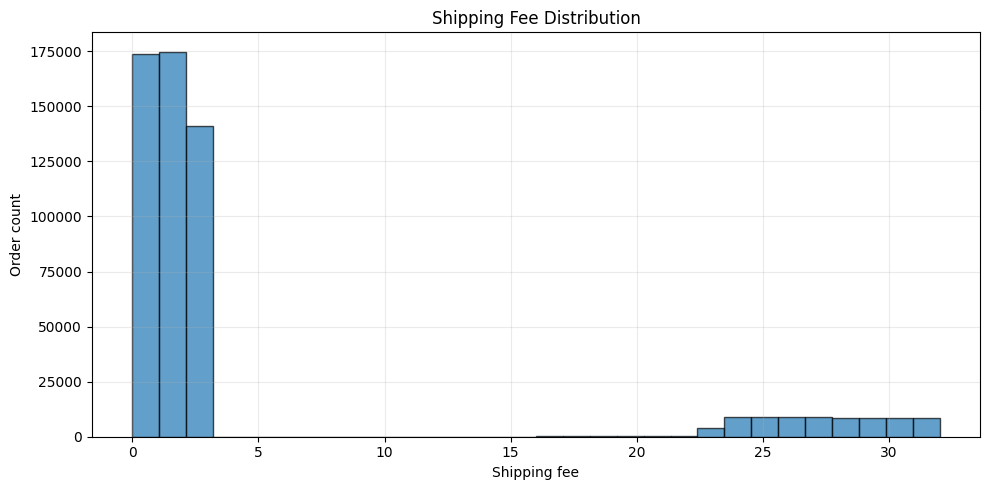

,order_id_std,analysis_date,shipping_fee_std,order_value_std,region_std,shipping_fee_ratio
522927,768302,2021-07-01,32.0000,"3,438.6800",West,0.0093
446231,655102,2019-03-28,32.0000,"1,715.6000",East,0.0187
462840,679648,2019-08-03,32.0000,"1,199.0100",Central,0.0267
83019,122134,2013-10-13,32.0000,"4,860.3300",East,0.0066
458277,672907,2019-06-28,32.0000,"3,549.1500",East,0.0090
251811,370034,2016-04-02,32.0000,"3,877.0000",East,0.0083
464803,682519,2019-08-23,32.0000,"3,924.3200",East,0.0082
238514,350552,2016-01-01,32.0000,"3,160.2000",Central,0.0101
213573,313834,2015-08-17,32.0000,"2,424.4500",Central,0.0132
351605,516286,2017-07-18,32.0000,"2,644.7500",Central,0.0121


In [8]:
shipping_distribution = pd.DataFrame()

if not order_shipping.empty:
    fee = order_shipping['shipping_fee_std']
    shipping_distribution = pd.DataFrame([{
        'average_shipping_fee': fee.mean(),
        'median_shipping_fee': fee.median(),
        'std_shipping_fee': fee.std(),
        'p25_shipping_fee': fee.quantile(0.25),
        'p75_shipping_fee': fee.quantile(0.75),
        'p90_shipping_fee': fee.quantile(0.90),
        'p95_shipping_fee': fee.quantile(0.95),
        'free_shipping_rate': order_shipping['free_shipping_flag'].mean(),
        'high_shipping_fee_rate': order_shipping['shipping_fee_group'].eq('high_shipping_fee').mean(),
    }])
    display(shipping_distribution)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(fee.dropna(), bins=30, color='tab:blue', edgecolor='black', alpha=0.7)
    ax.set_title('Shipping Fee Distribution')
    ax.set_xlabel('Shipping fee')
    ax.set_ylabel('Order count')
    plt.tight_layout()
    plt.show()

    top_high_fee = order_shipping.sort_values('shipping_fee_std', ascending=False)[
        ['order_id_std', 'analysis_date', 'shipping_fee_std', 'order_value_std', 'region_std', 'shipping_fee_ratio']
    ].head(10)
    display(top_high_fee)
else:
    print('Shipping fee distribution cannot be computed because the order-level shipping dataset is unavailable.')

## 9. AOV by Shipping Fee Group

Compare order count, total order value, AOV, median value, and shipping-fee ratio by shipping-fee group.

,shipping_fee_group,order_count,total_order_value,average_order_value,median_order_value,average_shipping_fee,free_shipping_rate,avg_shipping_fee_ratio
2,low_shipping_fee,282704,"7,785,775,993.8200","27,540.3814","20,944.5500",0.8705,0.0000,0.0001
0,free_shipping,805,"21,718,352.2400","26,979.3196","20,015.9600",0.0000,1.0000,0.0000
3,medium_shipping_fee,226100,"5,734,305,522.1500","25,361.8112","18,489.0550",4.2145,0.0000,0.0012
1,high_shipping_fee,56458,"168,881,103.9000","2,991.2697","3,109.6050",28.5228,0.0000,0.0117


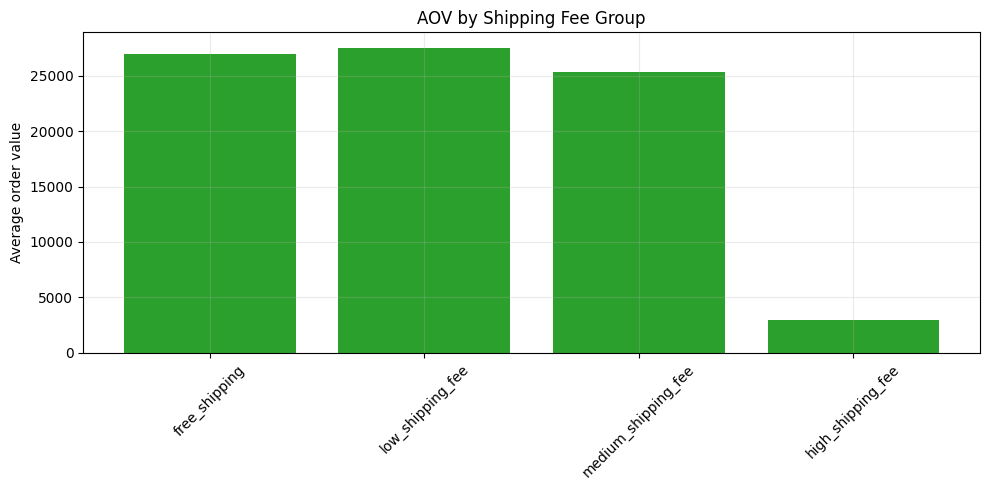

,shipping_type,order_count,total_order_value,average_order_value,median_order_value,average_shipping_fee
0,free_shipping,805,"21,718,352.2400","26,979.3196","20,015.9600",0.0000
1,paid_shipping,565262,"13,688,962,619.8700","24,217.0226","17,224.1200",4.9699


In [9]:
group_summary = pd.DataFrame()
free_vs_paid = pd.DataFrame()

if not order_shipping.empty:
    group_summary = order_shipping.groupby('shipping_fee_group').agg(
        order_count=('order_id_std', 'size'),
        total_order_value=('order_value_std', 'sum'),
        average_order_value=('order_value_std', 'mean'),
        median_order_value=('order_value_std', 'median'),
        average_shipping_fee=('shipping_fee_std', 'mean'),
        free_shipping_rate=('free_shipping_flag', 'mean'),
        avg_shipping_fee_ratio=('shipping_fee_ratio', 'mean'),
    ).reset_index().sort_values('average_order_value', ascending=False)
    display(group_summary)

    fig, ax = plt.subplots(figsize=(10, 5))
    ordered = group_summary.set_index('shipping_fee_group').reindex(['free_shipping', 'low_shipping_fee', 'medium_shipping_fee', 'high_shipping_fee', 'missing_fee']).dropna(how='all').reset_index()
    ax.bar(ordered['shipping_fee_group'].astype(str), ordered['average_order_value'], color='tab:green')
    ax.set_title('AOV by Shipping Fee Group')
    ax.set_ylabel('Average order value')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    free_vs_paid = order_shipping.assign(shipping_type=np.where(order_shipping['free_shipping_flag'], 'free_shipping', 'paid_shipping')).groupby('shipping_type').agg(
        order_count=('order_id_std', 'size'),
        total_order_value=('order_value_std', 'sum'),
        average_order_value=('order_value_std', 'mean'),
        median_order_value=('order_value_std', 'median'),
        average_shipping_fee=('shipping_fee_std', 'mean'),
    ).reset_index()
    display(free_vs_paid)

## 10. Shipping Fee vs Order Value

Compare shipping fee, shipping-fee ratio, and order value. This is order-level behavior only, not true conversion analysis.

Correlation between shipping fee and order value: -0.3712
Correlation between shipping fee ratio and order value: -0.3307


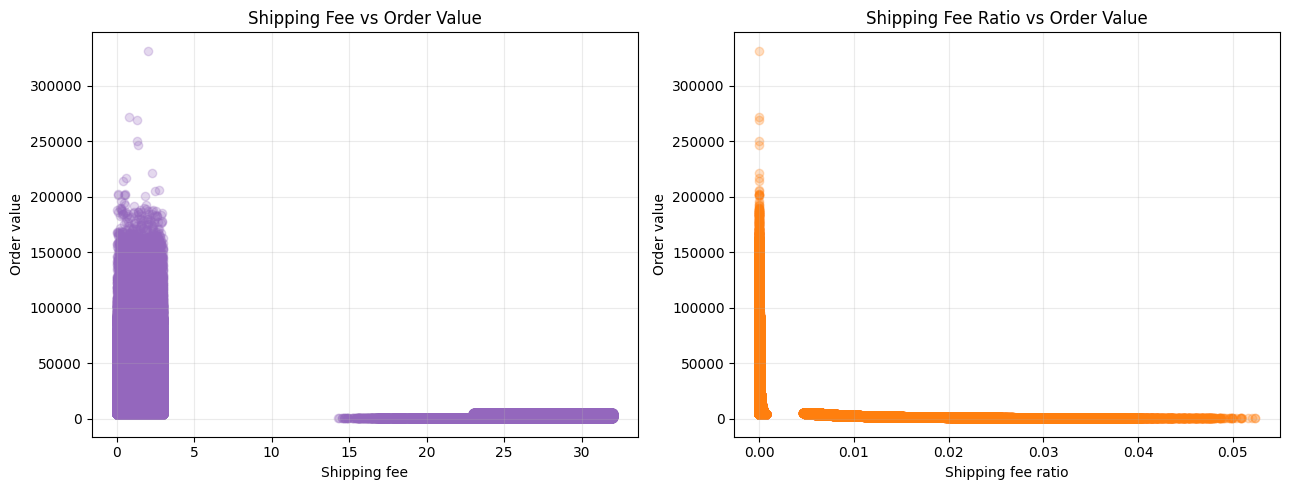

In [10]:
if not order_shipping.empty:
    corr_fee_value = order_shipping['shipping_fee_std'].corr(order_shipping['order_value_std'])
    corr_ratio_value = order_shipping['shipping_fee_ratio'].corr(order_shipping['order_value_std'])
    print(f'Correlation between shipping fee and order value: {corr_fee_value:.4f}')
    print(f'Correlation between shipping fee ratio and order value: {corr_ratio_value:.4f}')

    tmp = order_shipping.dropna(subset=['shipping_fee_std', 'order_value_std'])
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].scatter(tmp['shipping_fee_std'], tmp['order_value_std'], alpha=0.25, color='tab:purple')
    axes[0].set_title('Shipping Fee vs Order Value')
    axes[0].set_xlabel('Shipping fee')
    axes[0].set_ylabel('Order value')
    tmp2 = order_shipping.dropna(subset=['shipping_fee_ratio', 'order_value_std'])
    axes[1].scatter(tmp2['shipping_fee_ratio'], tmp2['order_value_std'], alpha=0.25, color='tab:orange')
    axes[1].set_title('Shipping Fee Ratio vs Order Value')
    axes[1].set_xlabel('Shipping fee ratio')
    axes[1].set_ylabel('Order value')
    plt.tight_layout()
    plt.show()

## 11. Shipping Fee by Region

Compare fee levels, free-shipping rates, AOV, and fee ratios by region. Small-sample regions should be interpreted carefully.

,region_std,order_count,average_shipping_fee,median_shipping_fee,p90_shipping_fee,free_shipping_rate,AOV,avg_shipping_fee_ratio
2,West,146923,5.3896,1.7700,25.8000,0.0013,"21,885.0297",0.0019
1,East,257756,4.8274,1.7200,24.8200,0.0015,"24,732.4272",0.0016
0,Central,161388,4.7907,1.7200,24.7500,0.0015,"25,530.6172",0.0016


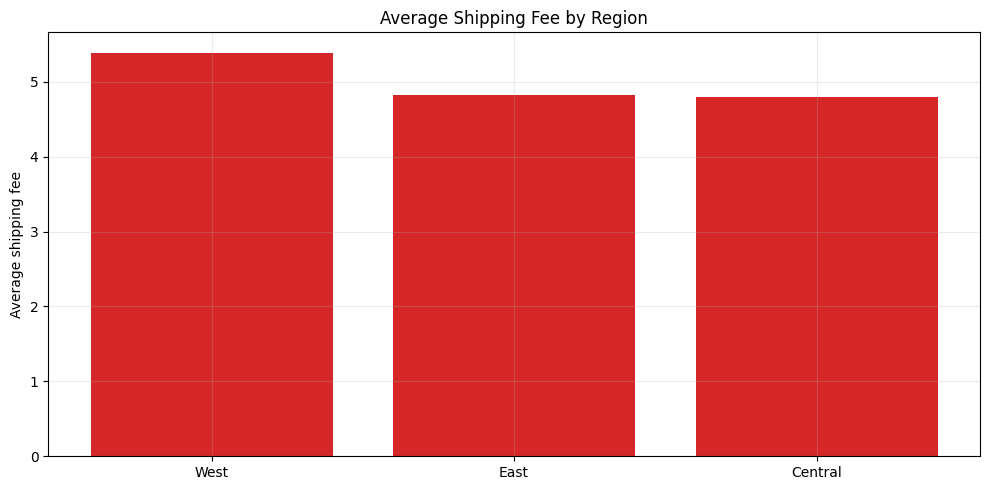

In [11]:
region_summary = pd.DataFrame()

if not order_shipping.empty and 'region_std' in order_shipping.columns and order_shipping['region_std'].notna().any():
    region_summary = order_shipping.groupby('region_std').agg(
        order_count=('order_id_std', 'size'),
        average_shipping_fee=('shipping_fee_std', 'mean'),
        median_shipping_fee=('shipping_fee_std', 'median'),
        p90_shipping_fee=('shipping_fee_std', lambda s: s.quantile(0.90)),
        free_shipping_rate=('free_shipping_flag', 'mean'),
        AOV=('order_value_std', 'mean'),
        avg_shipping_fee_ratio=('shipping_fee_ratio', 'mean'),
    ).reset_index().sort_values('average_shipping_fee', ascending=False)
    display(region_summary)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(region_summary['region_std'].astype(str), region_summary['average_shipping_fee'], color='tab:red')
    ax.set_title('Average Shipping Fee by Region')
    ax.set_ylabel('Average shipping fee')
    plt.tight_layout()
    plt.show()
else:
    print('Regional shipping-fee analysis is unavailable because region could not be identified.')

## 12. Shipping Fee Over Time

Track average shipping fee, free-shipping rate, high-shipping-fee ratio, and AOV over time.

,month,order_count,total_order_value,AOV,avg_shipping_fee,median_shipping_fee,free_shipping_ratio,high_shipping_fee_ratio
0,2012-07-01,4226,"104,310,987.1100","24,683.1489",5.1572,1.7400,0.0021,0.1081
1,2012-08-01,5504,"136,745,923.7400","24,844.8263",5.3694,1.7600,0.0015,0.1088
2,2012-09-01,4860,"118,944,234.6300","24,474.1224",5.3365,1.8100,0.0012,0.1068
3,2012-10-01,3773,"96,042,390.8100","25,455.1791",5.3937,1.7700,0.0019,0.1137
4,2012-11-01,3641,"87,132,220.7000","23,930.8489",6.0040,1.8100,0.0011,0.1299
5,2012-12-01,5649,"96,498,293.2800","17,082.3674",8.3908,2.0400,0.0011,0.1999
6,2013-01-01,3478,"84,458,920.1100","24,283.7608",5.4117,1.7500,0.0012,0.1130
7,2013-02-01,3962,"90,817,997.0000","22,922.2607",6.0808,1.8300,0.0013,0.1297
8,2013-03-01,5438,"117,749,458.7000","21,653.0818",5.6903,1.8000,0.0018,0.1210
9,2013-04-01,7747,"163,777,368.4500","21,140.7472",5.4483,1.7600,0.0010,0.1119


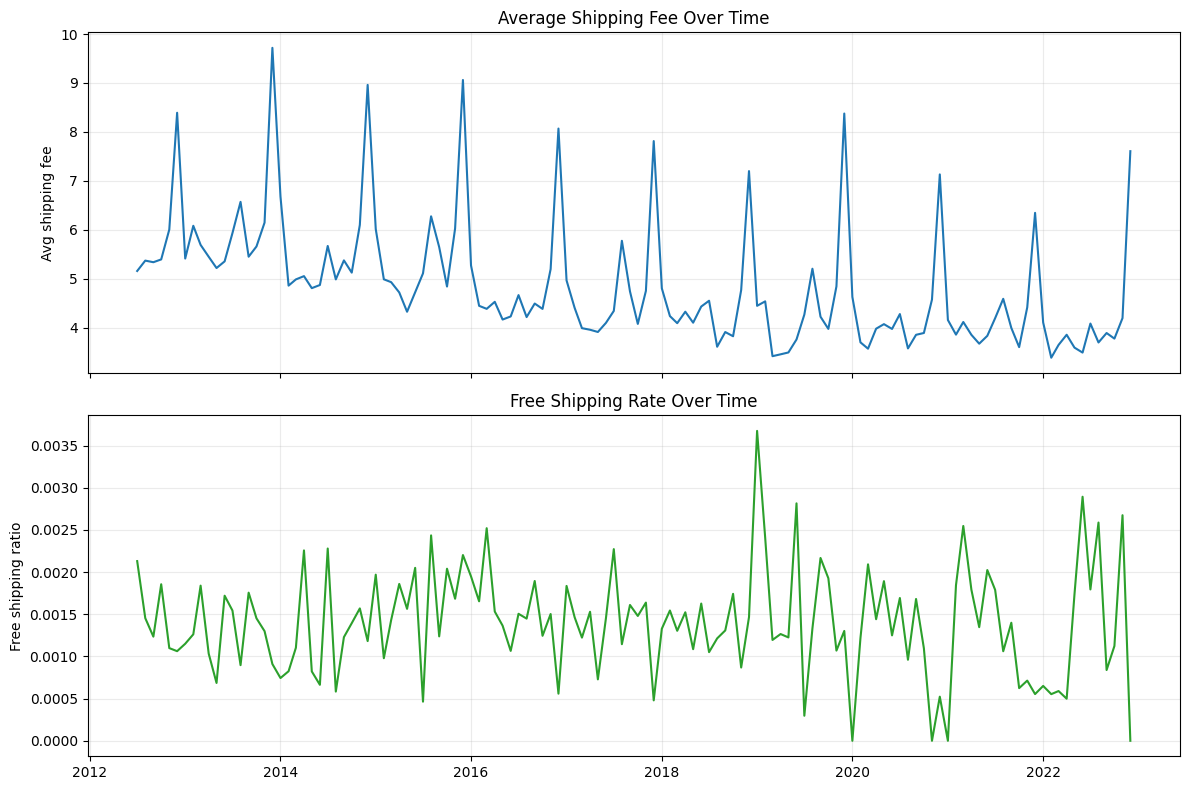

In [12]:
monthly_shipping = pd.DataFrame()

if not order_shipping.empty and order_shipping['analysis_date'].notna().any():
    tmp = order_shipping.dropna(subset=['analysis_date']).copy()
    tmp['month'] = tmp['analysis_date'].dt.to_period('M').dt.to_timestamp()
    monthly_shipping = tmp.groupby('month').agg(
        order_count=('order_id_std', 'size'),
        total_order_value=('order_value_std', 'sum'),
        AOV=('order_value_std', 'mean'),
        avg_shipping_fee=('shipping_fee_std', 'mean'),
        median_shipping_fee=('shipping_fee_std', 'median'),
        free_shipping_ratio=('free_shipping_flag', 'mean'),
        high_shipping_fee_ratio=('shipping_fee_group', lambda s: (s == 'high_shipping_fee').mean()),
    ).reset_index()
    display(monthly_shipping.head(12))

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(monthly_shipping['month'], monthly_shipping['avg_shipping_fee'], color='tab:blue')
    axes[0].set_title('Average Shipping Fee Over Time')
    axes[0].set_ylabel('Avg shipping fee')
    axes[1].plot(monthly_shipping['month'], monthly_shipping['free_shipping_ratio'], color='tab:green')
    axes[1].set_title('Free Shipping Rate Over Time')
    axes[1].set_ylabel('Free shipping ratio')
    plt.tight_layout()
    plt.show()
else:
    print('Shipping-fee time series could not be built because analysis dates are unavailable.')

## 13. Optional Cancellation and Order Status Analysis

If order status is available, compare cancellation rate by shipping-fee group.

,shipping_fee_group,order_count,cancellation_rate,average_order_value
0,free_shipping,805,0.0000,"26,979.3196"
1,high_shipping_fee,56458,0.0000,"2,991.2697"
2,low_shipping_fee,282704,0.0000,"27,540.3814"
3,medium_shipping_fee,226100,0.0000,"25,361.8112"


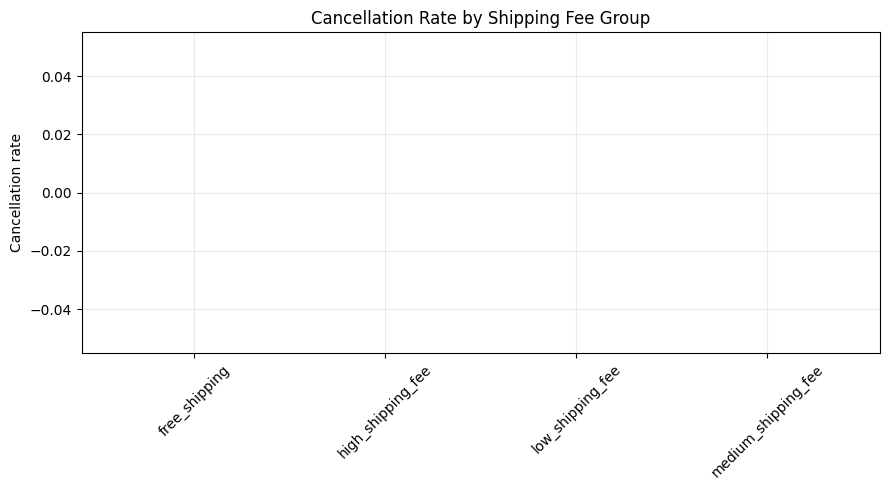

In [13]:
cancel_summary = pd.DataFrame()

if not order_shipping.empty and 'order_status_std' in order_shipping.columns and order_shipping['order_status_std'].notna().any():
    cancel_summary = order_shipping.groupby('shipping_fee_group').agg(
        order_count=('order_id_std', 'size'),
        cancellation_rate=('is_cancelled', 'mean'),
        average_order_value=('order_value_std', 'mean'),
    ).reset_index().sort_values('cancellation_rate', ascending=False)
    display(cancel_summary)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(cancel_summary['shipping_fee_group'].astype(str), cancel_summary['cancellation_rate'], color='tab:orange')
    ax.set_title('Cancellation Rate by Shipping Fee Group')
    ax.set_ylabel('Cancellation rate')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('Cancellation analysis is unavailable because order status could not be derived.')

## 14. Business Recommendation Insights

Summarize practical implications from the shipping-fee patterns. This remains descriptive and does not measure true conversion.

In [14]:
insight_rows = []

if not free_vs_paid.empty:
    free_aov = free_vs_paid.loc[free_vs_paid['shipping_type'] == 'free_shipping', 'average_order_value']
    paid_aov = free_vs_paid.loc[free_vs_paid['shipping_type'] == 'paid_shipping', 'average_order_value']
    if not free_aov.empty and not paid_aov.empty:
        insight_rows.append({'insight': 'free_shipping_vs_paid_aov', 'value': float(free_aov.iloc[0] - paid_aov.iloc[0])})

if not region_summary.empty:
    high_fee_threshold = region_summary['average_shipping_fee'].quantile(0.75)
    low_aov_threshold = region_summary['AOV'].quantile(0.25)
    concern_regions = region_summary[(region_summary['average_shipping_fee'] >= high_fee_threshold) & (region_summary['AOV'] <= low_aov_threshold)]
    display(concern_regions)

    region_summary['business_concern_flag'] = (
        (region_summary['average_shipping_fee'] >= high_fee_threshold) &
        (region_summary['avg_shipping_fee_ratio'] >= region_summary['avg_shipping_fee_ratio'].quantile(0.75))
    )
    print('Regions flagged for shipping-fee review')
    display(region_summary[region_summary['business_concern_flag']])

if insight_rows:
    display(pd.DataFrame(insight_rows))

,region_std,order_count,average_shipping_fee,median_shipping_fee,p90_shipping_fee,free_shipping_rate,AOV,avg_shipping_fee_ratio
2,West,146923,5.3896,1.7700,25.8000,0.0013,"21,885.0297",0.0019


Regions flagged for shipping-fee review


,region_std,order_count,average_shipping_fee,median_shipping_fee,p90_shipping_fee,free_shipping_rate,AOV,avg_shipping_fee_ratio,business_concern_flag
2,West,146923,5.3896,1.7700,25.8000,0.0013,"21,885.0297",0.0019,True


,insight,value
0,free_shipping_vs_paid_aov,"2,762.2970"


## 15. Leakage-Safe Shipping Forecast Feature Preview

Build lagged historical shipping-fee features only. Shipping-fee features are optional and difficult to use directly unless future fee rules are known.

In [15]:
feature_preview = pd.DataFrame()

if not monthly_shipping.empty:
    feat = monthly_shipping.sort_values('month').copy()
    feat['avg_shipping_fee_lag'] = feat['avg_shipping_fee'].shift(1)
    feat['free_shipping_ratio_lag'] = feat['free_shipping_ratio'].shift(1)
    feat['high_shipping_fee_ratio_lag'] = feat['high_shipping_fee_ratio'].shift(1)
    feat['avg_shipping_fee_roll_mean_3m'] = feat['avg_shipping_fee'].shift(1).rolling(3, min_periods=1).mean()
    feat['free_shipping_ratio_roll_mean_3m'] = feat['free_shipping_ratio'].shift(1).rolling(3, min_periods=1).mean()
    feat['region_shipping_fee_pressure_lag'] = region_summary['avg_shipping_fee_ratio'].mean() if not region_summary.empty else np.nan

    preview_cols = [
        'month', 'order_count', 'total_order_value', 'AOV', 'avg_shipping_fee',
        'median_shipping_fee', 'free_shipping_ratio', 'high_shipping_fee_ratio',
        'avg_shipping_fee_lag', 'free_shipping_ratio_lag', 'high_shipping_fee_ratio_lag',
        'avg_shipping_fee_roll_mean_3m', 'free_shipping_ratio_roll_mean_3m',
        'region_shipping_fee_pressure_lag'
    ]
    feature_preview = feat[preview_cols].head(20)
    display(feature_preview)

print('Shipping-fee features shown above are lagged historical aggregates only.')
print('Treat shipping-fee features as optional unless they show a strong relationship with AOV, Revenue, or order value.')
print('Do not use current-period or future shipping-fee outcomes directly unless fee rules are genuinely known before prediction.')

,month,order_count,total_order_value,AOV,avg_shipping_fee,median_shipping_fee,free_shipping_ratio,high_shipping_fee_ratio,avg_shipping_fee_lag,free_shipping_ratio_lag,high_shipping_fee_ratio_lag,avg_shipping_fee_roll_mean_3m,free_shipping_ratio_roll_mean_3m,region_shipping_fee_pressure_lag
0,2012-07-01,4226,"104,310,987.1100","24,683.1489",5.1572,1.7400,0.0021,0.1081,NaN,NaN,NaN,NaN,NaN,0.0017
1,2012-08-01,5504,"136,745,923.7400","24,844.8263",5.3694,1.7600,0.0015,0.1088,5.1572,0.0021,0.1081,5.1572,0.0021,0.0017
2,2012-09-01,4860,"118,944,234.6300","24,474.1224",5.3365,1.8100,0.0012,0.1068,5.3694,0.0015,0.1088,5.2633,0.0018,0.0017
3,2012-10-01,3773,"96,042,390.8100","25,455.1791",5.3937,1.7700,0.0019,0.1137,5.3365,0.0012,0.1068,5.2877,0.0016,0.0017
4,2012-11-01,3641,"87,132,220.7000","23,930.8489",6.0040,1.8100,0.0011,0.1299,5.3937,0.0019,0.1137,5.3666,0.0015,0.0017
5,2012-12-01,5649,"96,498,293.2800","17,082.3674",8.3908,2.0400,0.0011,0.1999,6.0040,0.0011,0.1299,5.5781,0.0014,0.0017
6,2013-01-01,3478,"84,458,920.1100","24,283.7608",5.4117,1.7500,0.0012,0.1130,8.3908,0.0011,0.1999,6.5962,0.0013,0.0017
7,2013-02-01,3962,"90,817,997.0000","22,922.2607",6.0808,1.8300,0.0013,0.1297,5.4117,0.0012,0.1130,6.6022,0.0011,0.0017
8,2013-03-01,5438,"117,749,458.7000","21,653.0818",5.6903,1.8000,0.0018,0.1210,6.0808,0.0013,0.1297,6.6278,0.0012,0.0017
9,2013-04-01,7747,"163,777,368.4500","21,140.7472",5.4483,1.7600,0.0010,0.1119,5.6903,0.0018,0.1210,5.7276,0.0014,0.0017


Shipping-fee features shown above are lagged historical aggregates only.
Treat shipping-fee features as optional unless they show a strong relationship with AOV, Revenue, or order value.
Do not use current-period or future shipping-fee outcomes directly unless fee rules are genuinely known before prediction.


## 16. Key Observations and Warnings

Summarize shipping-fee distribution, AOV associations, regional patterns, and optional historical feature recommendations.

In [16]:
summary_lines = ['KEY OBSERVATIONS AND WARNINGS']

if not shipping_distribution.empty:
    summary_lines.append(f"- Average shipping fee: {shipping_distribution.loc[0, 'average_shipping_fee']:.4f}.")
    summary_lines.append(f"- Median shipping fee: {shipping_distribution.loc[0, 'median_shipping_fee']:.4f}.")
    summary_lines.append(f"- Free shipping rate: {shipping_distribution.loc[0, 'free_shipping_rate']:.2%}.")

if not free_vs_paid.empty:
    free_aov = free_vs_paid.loc[free_vs_paid['shipping_type'] == 'free_shipping', 'average_order_value']
    paid_aov = free_vs_paid.loc[free_vs_paid['shipping_type'] == 'paid_shipping', 'average_order_value']
    if not free_aov.empty and not paid_aov.empty:
        relation = 'higher' if free_aov.iloc[0] > paid_aov.iloc[0] else 'lower'
        summary_lines.append(f"- Free-shipping orders are associated with {relation} AOV: {free_aov.iloc[0]:,.2f} vs paid-shipping {paid_aov.iloc[0]:,.2f}.")

if not order_shipping.empty:
    corr = order_shipping['shipping_fee_std'].corr(order_shipping['order_value_std'])
    direction = 'higher' if corr > 0.05 else 'lower' if corr < -0.05 else 'mixed'
    summary_lines.append(f"- High shipping fees are associated with {direction} order value under simple correlation ({corr:.4f}).")

if not region_summary.empty:
    top_regions = region_summary.sort_values('average_shipping_fee', ascending=False).head(3)
    summary_lines.append('- Regions with highest average shipping fees: ' + ', '.join(f"{r.region_std} ({r.average_shipping_fee:.2f})" for r in top_regions.itertuples()) + '.')
    concern = region_summary[region_summary.get('business_concern_flag', False) == True]
    if not concern.empty:
        summary_lines.append('- Regions where shipping fee may be a business concern: ' + ', '.join(f"{r.region_std}" for r in concern.itertuples()) + '.')

if shipping_warnings:
    summary_lines.append('- Shipping fee data quality warnings: ' + '; '.join(shipping_warnings))
else:
    summary_lines.append('- Shipping fee data quality warnings: none beyond the checks reported in notebook tables.')

summary_lines.append('- Business recommendations: review free-shipping threshold strategy only if free-shipping orders consistently show stronger AOV; inspect regions with high average shipping fee and high fee ratio for subsidy or pricing-threshold review; watch low-order-value groups where shipping-fee ratio is elevated.')
summary_lines.append('- Optional leakage-safe shipping-fee aggregate features: avg_shipping_fee_lag, free_shipping_ratio_lag, high_shipping_fee_ratio_lag, avg_shipping_fee_roll_mean_3m, and region_shipping_fee_pressure_lag.')
summary_lines.append('- Future shipping fee values must not be used directly unless fee rules are genuinely known before prediction.')
summary_lines.append('- Causal caution: this is observational EDA. Shipping fees can vary with geography, package weight, carrier rules, promotions, and order composition.')

print('\n'.join(summary_lines))

KEY OBSERVATIONS AND WARNINGS
- Average shipping fee: 4.9629.
- Median shipping fee: 1.7300.
- Free shipping rate: 0.14%.
- Free-shipping orders are associated with higher AOV: 26,979.32 vs paid-shipping 24,217.02.
- High shipping fees are associated with lower order value under simple correlation (-0.3712).
- Regions with highest average shipping fees: West (5.39), East (4.83), Central (4.79).
- Regions where shipping fee may be a business concern: West.
- Shipping fee data quality warnings: none beyond the checks reported in notebook tables.
- Business recommendations: review free-shipping threshold strategy only if free-shipping orders consistently show stronger AOV; inspect regions with high average shipping fee and high fee ratio for subsidy or pricing-threshold review; watch low-order-value groups where shipping-fee ratio is elevated.
- Optional leakage-safe shipping-fee aggregate features: avg_shipping_fee_lag, free_shipping_ratio_lag, high_shipping_fee_ratio_lag, avg_shipping_f